# 01 - Exploration des données — EDA

Objectif : comprendre la structure des données, identifier les problèmes (valeurs manquantes, déséquilibre) et repérer les variables utiles pour le modèle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Chargement des données

On charge la table principale `application_train.csv` — c'est la table de référence : **1 ligne = 1 client**, avec sa variable cible `TARGET`.

In [2]:
# Chemin vers les données
DATA_PATH = '../data/'

# Table principale : 1 ligne = 1 client, avec la variable cible TARGET
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')

print(f'Dimensions : {app_train.shape}')
app_train.head()

Dimensions : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Analyse :** 307 511 clients, 122 colonnes. On repère déjà des `NaN` sur la ligne 3 (client 100006) dans les colonnes `AMT_REQ_CREDIT_BUREAU_*` — ce client n'a probablement pas de demande de crédit bureau enregistrée.

## 2. Variable cible (TARGET)

`TARGET = 0` → bon client, `TARGET = 1` → défaut de paiement.

On commence par mesurer le **déséquilibre des classes** : si une classe est très minoritaire, le modèle aura tendance à l'ignorer.

In [3]:
# Distribution de la variable cible
print(app_train['TARGET'].value_counts())
print()
print(app_train['TARGET'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.93 %
1     8.07 %
Name: proportion, dtype: object


**Analyse :** Le déséquilibre est fort : seulement **8% de défauts**. Un modèle qui prédit toujours "bon client" aurait 92% d'accuracy sans rien apprendre — c'est pourquoi l'accuracy est inutile ici. On utilisera l'**AUC** et un **score métier** basé sur le coût des erreurs.

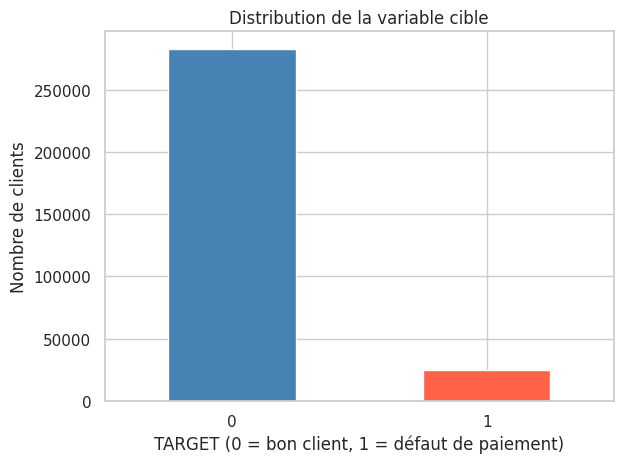

In [4]:
# Visualisation du déséquilibre des classes
fig, ax = plt.subplots()
app_train['TARGET'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Distribution de la variable cible')
ax.set_xlabel('TARGET (0 = bon client, 1 = défaut de paiement)')
ax.set_ylabel('Nombre de clients')
ax.set_xticklabels(['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


## 3. Valeurs manquantes

Beaucoup d'algorithmes ne tolèrent pas les valeurs manquantes. On identifie les colonnes concernées et leur taux, pour décider plus tard : **supprimer** la colonne ou **imputer** (remplacer par la moyenne, la médiane...).

In [5]:
# Calcul du % de valeurs manquantes par colonne
missing = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]  # on garde uniquement les colonnes avec au moins un NaN

print(f'{len(missing)} colonnes avec des valeurs manquantes sur {app_train.shape[1]}')
missing.head(20)

67 colonnes avec des valeurs manquantes sur 122


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

**Analyse :** 67 colonnes sur 122 ont des valeurs manquantes. Les colonnes liées au logement (`COMMONAREA`, `LIVINGAPARTMENTS`...) sont manquantes à ~70% — probablement car beaucoup de clients ne vivent pas dans un appartement. `OWN_CAR_AGE` est à 66% car la majorité des clients n'a pas de voiture. Ces absences ont souvent un **sens métier**, on ne les supprimera pas sans réflexion.

## 4. Types de colonnes

Les modèles ML ne traitent pas pareil les variables **numériques** et **catégorielles**. On fait un inventaire pour savoir ce qu'il faudra encoder.

In [6]:
# Répartition des types de colonnes
print(app_train.dtypes.value_counts())

float64    65
int64      41
object     16
Name: count, dtype: int64


**Analyse :** 106 colonnes numériques (float + int), 16 catégorielles. Les colonnes catégorielles (ex: `NAME_CONTRACT_TYPE`, `CODE_GENDER`) devront être **encodées** avant l'entraînement — on verra ça dans le notebook de preprocessing.

## 5. Aperçu de la population

Avant d'analyser les corrélations, on visualise la répartition des variables catégorielles clés pour comprendre qui sont les clients du dataset.

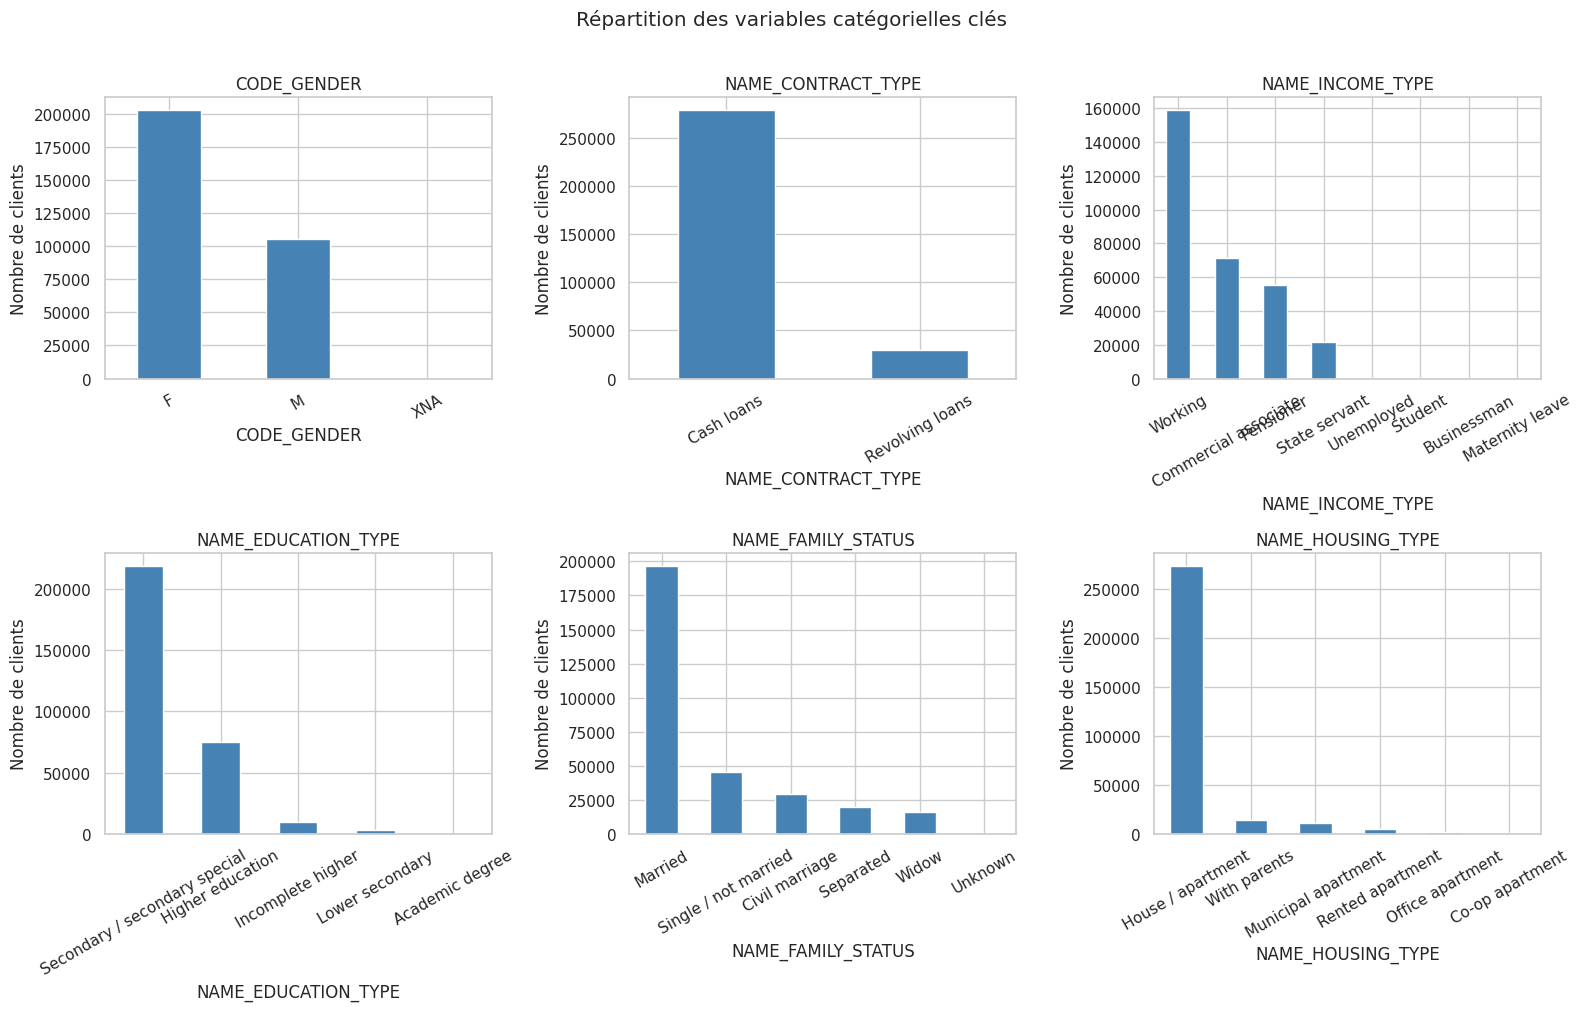

In [7]:
cols_cat = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE',
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # Comptage et tri par fréquence
    counts = app_train[col].value_counts()
    counts.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Répartition des variables catégorielles clés', y=1.01)
plt.tight_layout()
plt.show()

**Analyse :** La population est majoritairement composée de **femmes** (~65%), de clients avec un **Cash loan** plutôt qu'un Revolving loan, de **salariés** (`Working`) comme principale source de revenus, avec un niveau d'éducation **secondaire** dominant. La plupart sont **mariés** et vivent dans une **maison/appartement**. C'est une population assez homogène — les modèles devront bien généraliser sur les sous-groupes minoritaires.

## 6. Corrélations avec TARGET

On mesure la **corrélation linéaire** entre chaque variable numérique et TARGET. Une corrélation élevée (en valeur absolue) indique une variable potentiellement utile au modèle.

In [8]:
# Corrélation de chaque variable numérique avec TARGET
# On prend la valeur absolue pour comparer l'intensité peu importe le sens
correlations = app_train.select_dtypes(include=[np.number]).corr()['TARGET'].drop('TARGET')
correlations = correlations.abs().sort_values(ascending=False)

print('Top 15 variables les plus corrélées avec TARGET :')
print(correlations.head(15))

Top 15 variables les plus corrélées avec TARGET :
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
Name: TARGET, dtype: float64


**Analyse :** Les corrélations sont globalement faibles (max ~0.18). C'est normal sur des données réelles. Les `EXT_SOURCE_1/2/3` dominent nettement — ce sont des scores de solvabilité calculés par des organismes externes. `DAYS_BIRTH` (âge du client) arrive ensuite : les clients plus jeunes ont statistiquement plus de défauts.

## 7. Distribution des variables clés

### 7.1 Scores de solvabilité externes (EXT_SOURCE)

Les `EXT_SOURCE_1/2/3` sont des **scores de solvabilité externes** — les plus corrélés avec TARGET. On trace leur distribution pour les deux classes : si les courbes sont bien séparées, la variable est discriminante.

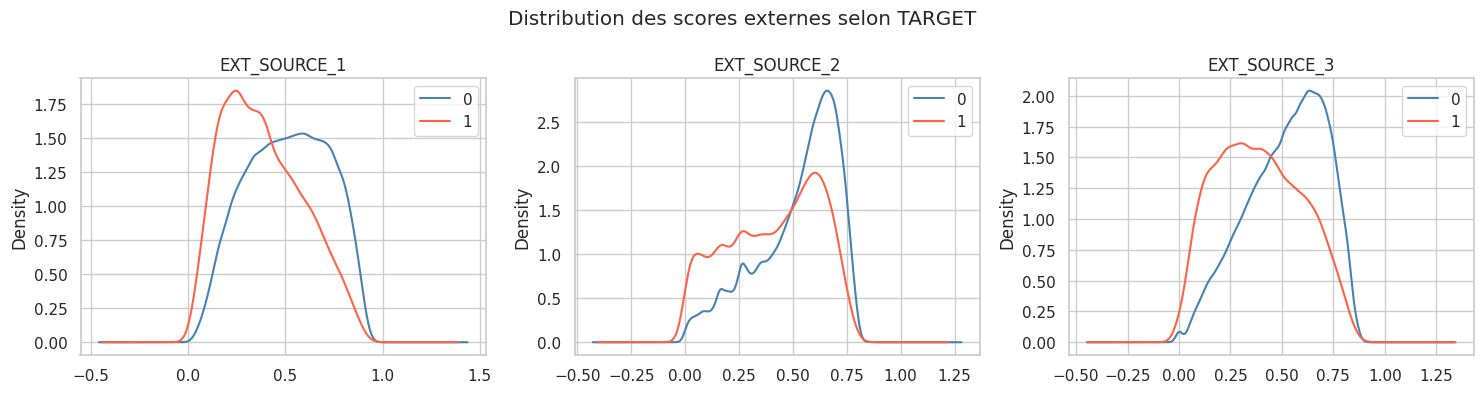

In [9]:
# Distribution des EXT_SOURCE par classe cible
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    app_train[app_train['TARGET'] == 0][col].dropna().plot(kind='kde', ax=axes[i], label='0', color='steelblue')
    app_train[app_train['TARGET'] == 1][col].dropna().plot(kind='kde', ax=axes[i], label='1', color='tomato')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Distribution des scores externes selon TARGET')
plt.tight_layout()
plt.show()

**Analyse :** Les courbes des deux classes sont clairement décalées pour les 3 sources. Les clients en défaut (rouge) ont des scores externes plus **bas** — ce qui confirme leur pouvoir prédictif. Ces variables seront très importantes dans nos modèles.

### 7.2 Distribution de l'âge (DAYS_BIRTH)

`DAYS_BIRTH` est en jours négatifs. On le convertit en âge pour le rendre lisible, puis on compare les deux classes.

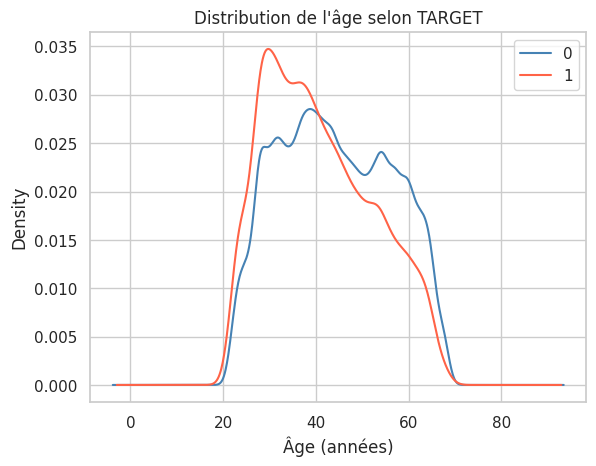

           count  mean   std   min   25%   50%   75%   max
TARGET                                                    
0       282686.0  44.2  12.0  20.5  34.3  43.5  54.2  69.1
1        24825.0  40.8  11.5  21.0  31.2  39.1  49.4  69.0


In [10]:
# Conversion en âge (valeur absolue divisée par 365)
app_train['AGE'] = -app_train['DAYS_BIRTH'] / 365

# Distribution par classe
app_train[app_train['TARGET'] == 0]['AGE'].plot(kind='kde', label='0', color='steelblue')
app_train[app_train['TARGET'] == 1]['AGE'].plot(kind='kde', label='1', color='tomato')

plt.xlabel('Âge (années)')
plt.title("Distribution de l'âge selon TARGET")
plt.legend()
plt.show()

# Statistiques descriptives par classe
print(app_train.groupby('TARGET')['AGE'].describe().round(1))

**Analyse :** Les clients en défaut sont en moyenne **3.4 ans plus jeunes** (40.8 vs 44.2 ans). La courbe rouge est décalée vers la gauche — les jeunes clients ont statistiquement plus de mal à rembourser, probablement par manque d'historique financier et de stabilité professionnelle.

### 7.3 Ancienneté professionnelle (DAYS_EMPLOYED)

`DAYS_EMPLOYED` est aussi en jours négatifs. Mais attention : la valeur **365243** est une anomalie connue du dataset — elle code les clients sans emploi (retraités, chômeurs). On doit la traiter avant d'analyser.

Nombre de valeurs 365243 : 55374


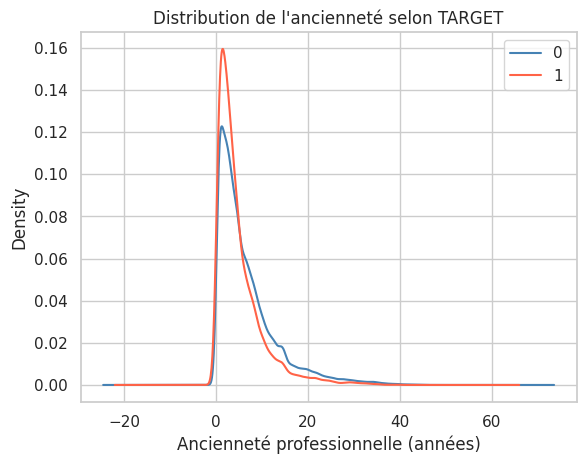

           count  mean  std  min  25%  50%  75%   max
TARGET                                               
0       230302.0   6.7  6.5 -0.0  2.2  4.6  8.9  49.1
1        21835.0   5.0  5.1 -0.0  1.6  3.4  6.5  44.0


In [11]:
# Vérification de la valeur aberrante
print("Nombre de valeurs 365243 :", (app_train['DAYS_EMPLOYED'] == 365243).sum())

# Remplacement par NaN puis conversion en années
app_train['YEARS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)
app_train['YEARS_EMPLOYED'] = -app_train['YEARS_EMPLOYED'] / 365

# Distribution par classe (après nettoyage)
app_train[app_train['TARGET'] == 0]['YEARS_EMPLOYED'].dropna().plot(kind='kde', label='0', color='steelblue')
app_train[app_train['TARGET'] == 1]['YEARS_EMPLOYED'].dropna().plot(kind='kde', label='1', color='tomato')

plt.xlabel("Ancienneté professionnelle (années)")
plt.title("Distribution de l'ancienneté selon TARGET")
plt.legend()
plt.show()

print(app_train.groupby('TARGET')['YEARS_EMPLOYED'].describe().round(1))

**Analyse :** 55 374 clients avaient la valeur aberrante 365243 (18% du dataset) — remplacée par NaN. Les clients en défaut ont une ancienneté professionnelle moyenne plus courte (**5.0 vs 6.7 ans**) : moins de stabilité dans l'emploi est associé à plus de risque.

## Conclusion

Ce que l'EDA nous a appris, et ce qu'on devra faire dans le preprocessing :

| Observation | Action à prévoir |
|---|---|
| 8% de défauts seulement | Utiliser `class_weight='balanced'` ou SMOTE |
| 67 colonnes avec NaN (jusqu'à 70%) | Imputer (médiane pour numériques, mode pour catégorielles) |
| `DAYS_EMPLOYED` contient 365243 | Remplacer par NaN avant imputation |
| 16 colonnes catégorielles | Encoder (Label Encoding ou One-Hot) |
| `EXT_SOURCE_1/2/3` très discriminants | À conserver impérativement dans le modèle |
| Clients plus jeunes = plus de défauts | `AGE` sera une feature utile |

**Prochaine étape →** `02_preprocessing.ipynb` : nettoyage, encodage, jointures et sauvegarde du dataset final.